# Artificial Intellgence Assignment 2

**Student Name:** WANG Renjia

**Student ID:** 2023040901026

**Major:** Industrial Engineering

The Iris dataset is one of the most iconic and widely used benchmarks in the field of machine learning and statistics. First introduced by Ronald A. Fisher in 1936, it comprises measurements of sepal length, sepal width, petal length, and petal width from 150 iris flowers across three species: Iris-setosa, Iris-versicolor, and Iris-virginica. Its simplicity, balanced class distribution, and clear feature separability make it an ideal teaching tool for illustrating fundamental classification techniques. In this document, we explore the dataset through exploratory data analysis and implement five core machine learning algorithms—from logistic regression to support vector machines—entirely from scratch using NumPy and foundational Python libraries. Each model is evaluated under both standard and challenging train-test splits to assess generalization performance and robustness.

In [33]:
from ucimlrepo import fetch_ucirepo 

# Fetch Iris dataset (ID 53)
iris = fetch_ucirepo(id=53) 

# Data as pandas dataframes 
X = iris.data.features 
y = iris.data.targets 

print(X.head())
print(y.value_counts())


   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
class          
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Success: 'iris_dataset.csv' has been saved to your folder.


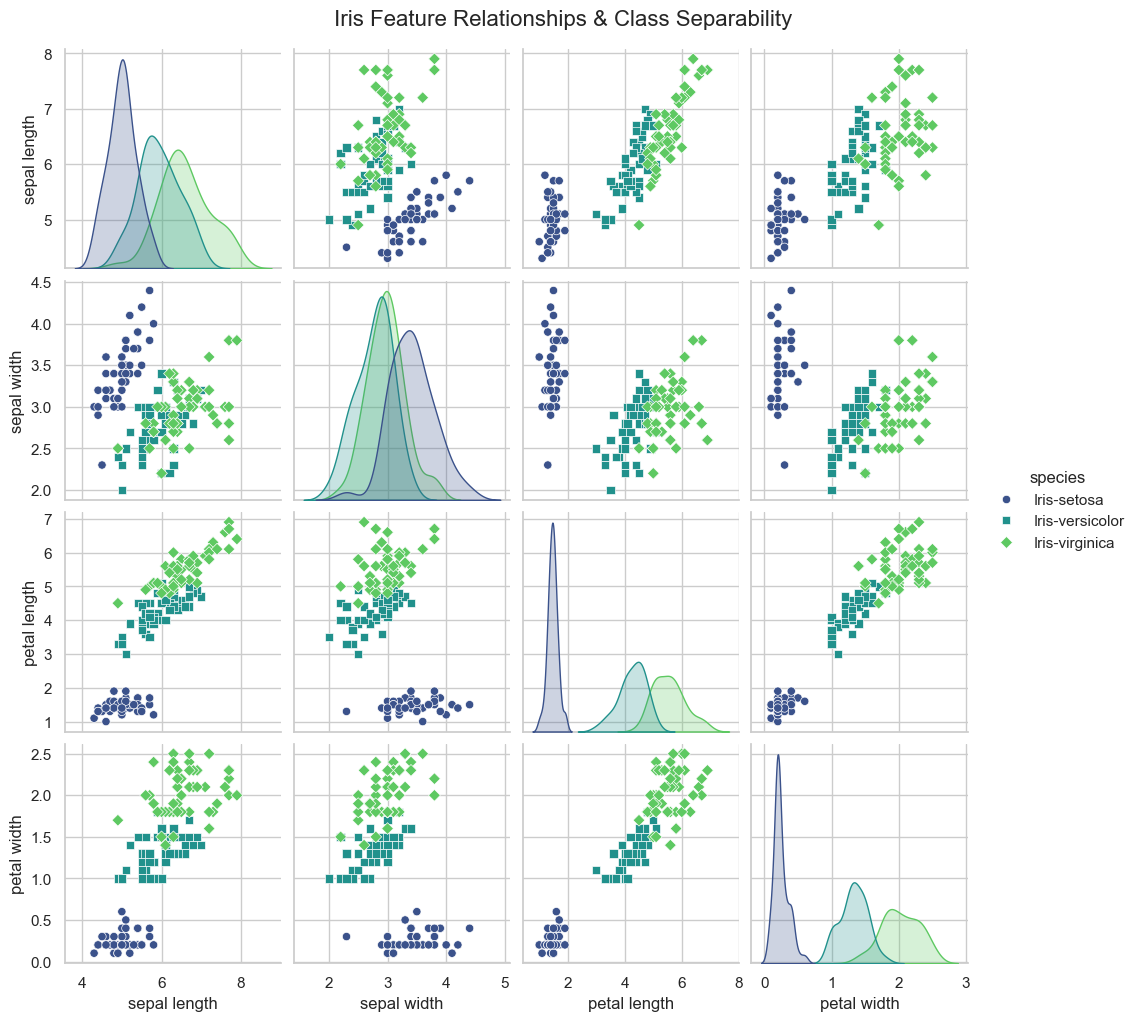


Preview of the combined dataset:
   sepal length  sepal width  petal length  petal width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_full = X.copy()
df_full['species'] = y

# SAVE THE DATASET TO CSV
df_full.to_csv('iris_dataset.csv', index=False)
print("Success: 'iris_dataset.csv' has been saved to your folder.")

sns.set_theme(style="whitegrid")

# Create a pairplot: This is the gold standard for Iris visualization
# It shows scatter plots for every pair of features and KDEs on the diagonal
g = sns.pairplot(df_full, hue='species', palette='viridis', markers=["o", "s", "D"])
g.fig.suptitle("Iris Feature Relationships & Class Separability", y=1.02, fontsize=16)

plt.tight_layout
plt.show()

# 4. Check the first few rows to confirm it looks right
print("\nPreview of the combined dataset:")
print(df_full.head())

## Evaluation Metrics for Classification

| Metric | Mathematical Formula | Description |
| :--- | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Ratio of correct predictions to total samples. |
| **Precision** | $\frac{TP}{TP + FP}$ | Ability of the classifier not to label a negative sample as positive. |
| **Recall** | $\frac{TP}{TP + FN}$ | Ability of the classifier to find all the positive samples. |
| **F1-Score** | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | The harmonic mean of Precision and Recall. |

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Encode the Species names into numbers (0, 1, 2)
le = LabelEncoder()
y_class = le.fit_transform(df_full['species'])
X_class = df_full.drop('species', axis=1)

# 2. Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

# 3. Scaling (Crucial for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('The shape of the scaled training data X is:', X_train_scaled.shape)
print('The shape of the training labels y is:', y_train.shape)
print('The shape of the scaled test data X is:', X_test_scaled.shape)
print('The shape of the test labels y is:', y_test.shape)

# Helper function to plot Confusion Matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

The shape of the scaled training data X is: (105, 4)
The shape of the training labels y is: (105,)
The shape of the scaled test data X is: (45, 4)
The shape of the test labels y is: (45,)


## Logistic Regression (Probabilistic Linear Classifier)

### 1. Linear Score Calculation (Forward Pass)
The model computes a raw score (logit) for each of the $K$ classes:
$$Z = XW + b$$
* **$X$**: Input feature matrix $(N \times D)$
* **$W$**: Weight matrix $(D \times K)$
* **$b$**: Bias vector $(1 \times K)$

### 2. Softmax Function (Probability Mapping)
To convert raw scores into probabilities $\in [0, 1]$ that sum to $1$:
$$P(y=k | x) = \hat{y}_k = \frac{e^{z_k - \max(Z)}}{\sum_{j=1}^{K} e^{z_j - \max(Z)}}$$
*The term $\max(Z)$ is subtracted for **numerical stability** to prevent $e^z$ from overflowing to infinity.*

### 3. Objective Function (Cross-Entropy Loss)
The model minimizes the negative log-likelihood between the predicted probability $\hat{y}$ and the One-Hot encoded target $y$:
$$J(W, b) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

### 4. Optimization (Gradient Descent)
The gradient of the Cross-Entropy loss with respect to the weights simplifies to the prediction error:

**Weight Gradient:**
$$\nabla_W J = \frac{1}{N} X^T (\hat{Y} - Y)$$

**Update Rule:**
$$W_{new} = W_{old} - \eta \cdot \nabla_W J$$
*(where $\eta$ is the `learning_rate`)*

### 5. Prediction Logic
The final class is determined by selecting the index with the highest probability:
$$\text{prediction} = \arg\max(\hat{Y}, \text{axis}=1)$$

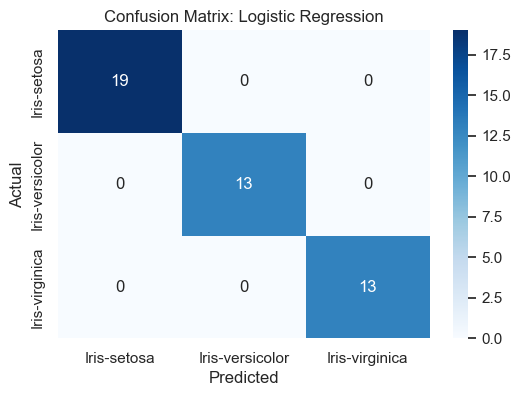

Accuracy: 1.0000



In [9]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.1, iterations=5000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def _softmax(self, z):
        # Subtracting np.max(z) is a numerical stability trick to prevent overflow
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        # Converts [0, 1, 2] into [[1,0,0], [0,1,0], [0,0,1]]
        one_hot = np.zeros((y.size, n_classes))
        one_hot[np.arange(y.size), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Initialize weights: (features x classes)
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        y_encoded = self._one_hot(y, n_classes)

        for _ in range(self.iterations):
            # 1. Forward Pass
            scores = np.dot(X, self.weights) + self.bias
            probs = self._softmax(scores)

            # 2. Compute Gradients
            # The derivative of Cross-Entropy with Softmax is elegantly simple: (Probs - Target)
            error = probs - y_encoded
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error, axis=0)

            # 3. Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        scores = np.dot(X, self.weights) + self.bias
        probs = self._softmax(scores)
        # Return the class index with the highest probability
        return np.argmax(probs, axis=1)
    
# 1. Create the model
model = LogisticRegression(learning_rate=0.1, iterations=5000)

# 2. Fit the data
model.fit(X_train_scaled, y_train)

# 3. Get predictions
preds = model.predict(X_test_scaled)

# 4. View results
plot_cm(y_test, preds, "Logistic Regression")

## Decision Tree Classifier
### 1. Node Impurity (Gini Index)
To handle multiple classes (Setosa, Versicolor, Virginica), we calculate the Gini Impurity $G$ at each node. It represents the probability of a random sample being incorrectly classified:
$$G = 1 - \sum_{i=1}^{C} p_i^2$$
* **$C$**: Total number of classes (3 for Iris).
* **$p_i$**: The proportion of samples belonging to class $i$ in the current node.

### 2. Optimal Split Search (Mid-point Strategy)
Instead of splitting exactly on a feature value from the training set, the model calculates the **mid-points** between sorted unique values to find a more generalized boundary:
$$\text{thresholds} = \frac{v_i + v_{i+1}}{2}$$
For every feature and every mid-point, we calculate the **Weighted Gini Impurity**:
$$G_{split} = \frac{N_{left}}{N_{total}} G_{left} + \frac{N_{right}}{N_{total}} G_{right}$$
The algorithm selects the (feature, threshold) pair that minimizes $G_{split}$.

### 3. Stopping Criteria (Regularization)
To prevent the tree from overfitting (growing too complex and memorizing noise), three constraints are applied:
1.  **Max Depth**: Limits the number of vertical splits.
2.  **Min Samples Split**: A node is only split if it contains at least $n$ samples.
3.  **Purity**: If all samples in a node belong to one class ($G=0$), splitting stops.

### 4. Leaf Node Prediction
Once a stopping criterion is met, the node becomes a **Leaf**. It predicts the class $\hat{y}$ that has the highest frequency (mode) among the samples remaining in that partition:
$$\hat{y} = \text{mode}(y_{node})$$


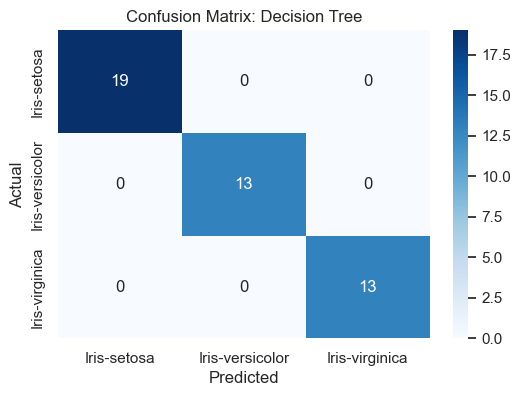

Accuracy: 1.0000



In [10]:
import numpy as np

class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, y):
        """Calculate Gini Impurity for any number of classes."""
        m = len(y)
        if m == 0: return 0
        # Count occurrences of each class 0, 1, 2...
        counts = np.unique(y, return_counts=True)[1]
        probabilities = counts / m
        return 1.0 - np.sum(probabilities ** 2)

    def _best_split(self, X, y):
        best_gini = 999
        split_idx, split_thresh = None, None
        n_samples, n_features = X.shape

        for idx in range(n_features):
            # Sort values to find mid-points
            thresholds = np.unique(X[:, idx])
            # Calculate mid-points between sorted unique values
            mid_points = (thresholds[:-1] + thresholds[1:]) / 2
            
            for thresh in mid_points:
                left_idx = np.where(X[:, idx] <= thresh)[0]
                right_idx = np.where(X[:, idx] > thresh)[0]
                
                if len(left_idx) == 0 or len(right_idx) == 0:
                    continue
                
                # Weighted Gini calculation
                g = (len(left_idx) * self._gini(y[left_idx]) + 
                     len(right_idx) * self._gini(y[right_idx])) / n_samples
                
                if g < best_gini:
                    best_gini, split_idx, split_thresh = g, idx, thresh
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        unique_classes, counts = np.unique(y, return_counts=True)
        
        # Determine the majority class at this node
        predicted_class = unique_classes[np.argmax(counts)] if n_samples > 0 else None

        # Stopping Criteria
        if (depth < self.max_depth and 
            n_samples >= self.min_samples_split and 
            len(unique_classes) > 1):
            
            idx, thresh = self._best_split(X, y)
            if idx is not None:
                indices_left = X[:, idx] <= thresh
                node = {
                    'feature_index': idx,
                    'threshold': thresh,
                    'left': self._build_tree(X[indices_left], y[indices_left], depth + 1),
                    'right': self._build_tree(X[~indices_left], y[~indices_left], depth + 1),
                }
                return node
        
        return predicted_class

    def fit(self, X, y):
        # Ensure input is a numpy array
        X = np.array(X)
        y = np.array(y)
        self.tree = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature_index']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.tree) for x in X])

# Use max_depth=3 for Iris to prevent overfitting
dt_model = DecisionTreeScratch(max_depth=3, min_samples_split=2)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

plot_cm(y_test, dt_preds, "Decision Tree")

## Random Forest

### 1. Variance Decomposition and Correlation
The power of Random Forest lies in the formula for the variance of the average of $B$ identical (but correlated) random variables:
$$\text{Var}(\text{RF}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$
* **$\sigma^2$**: The variance of a single tree (usually high).
* **$\rho$**: The correlation between trees.
* **$B$**: The number of trees.
By using **Bootstrap Sampling** and **Random Feature Selection**, we mathematically force $\rho$ to decrease. As $B$ increases, the second term vanishes, and the overall variance of the model is reduced to $\rho \sigma^2$.

### 2. The Bootstrap Limit
In Bootstrap sampling, each sample has a probability of $1/N$ of being picked. The probability of a specific sample *not* being picked in $N$ tries is:
$$P(\text{not picked}) = \left(1 - \frac{1}{N}\right)^N$$
Using the limit $\lim_{n \to \infty} (1 - \frac{1}{n})^n = \frac{1}{e}$, we find that approximately $36.8\%$ of the data is left out for each tree. This "Out-of-Bag" (OOB) data acts as a built-in cross-validation set.

### 3. Strength vs. Correlation (Breiman's Bound)
The generalization error $GE$ of a Random Forest is bounded by:
$$GE \leq \frac{\rho(1 - s^2)}{s^2}$$
* **$s$**: The "strength" (accuracy) of the individual trees.
* **$\rho$**: The average correlation between them.
To improve accuracy, we must mathematically balance making trees "strong" (deep enough) while keeping them "de-correlated" (different from each other).

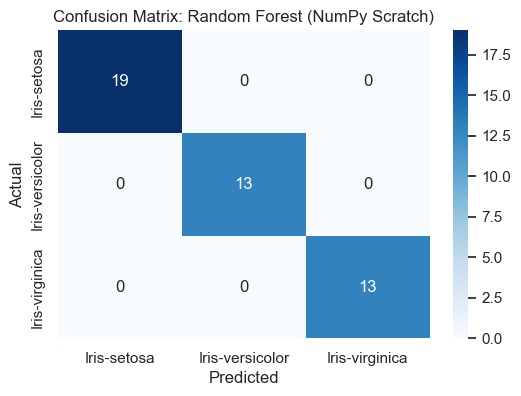

Accuracy: 1.0000



In [11]:
import numpy as np

class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=5, min_samples_split=2, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees = []

    def _bootstrap_sample(self, X, y):
        """Create a random sample with replacement."""
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def fit(self, X, y):
        self.trees = []
        X = np.array(X)
        y = np.array(y)
        
        for _ in range(self.n_trees):
            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            
            # 1. Bootstrap the data (Bagging)
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # 2. Train the tree
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        X = np.array(X)
        # 3. Collect predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # 4. Majority Vote (Mode) across the first axis
        # tree_preds shape: (n_trees, n_samples)
        final_preds = []
        for i in range(X.shape[0]):
            sample_preds = tree_preds[:, i]
            # Find the most frequent class for this sample
            unique_classes, counts = np.unique(sample_preds, return_counts=True)
            most_frequent = unique_classes[np.argmax(counts)]
            final_preds.append(most_frequent)
            
        return np.array(final_preds)

# --- Training in Jupyter ---
# We use 10 trees to see the ensemble effect
rf_model = RandomForestScratch(n_trees=20, max_depth=3)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

plot_cm(y_test, rf_preds, "Random Forest (NumPy Scratch)")

## Support Vector Machine (SVM)

Support Vector Machines are supervised learning models that solve a **constrained optimization problem**. The goal is to find a hyperplane that separates classes with the maximum possible margin.

---

### 1. The Decision Hyperplane
For a dataset with features $x \in \mathbb{R}^d$ and labels $y \in \{-1, 1\}$, the decision boundary is defined by the set of points satisfying:
$$w^T x + b = 0$$
Where $w$ is the weight vector (normal to the hyperplane) and $b$ is the bias. The classifier function is:
$$f(x) = \text{sign}(w^T x + b)$$

### 2. The Geometric Margin
The distance from any point $x_i$ to the hyperplane is $\frac{|w^T x_i + b|}{\|w\|}$. To ensure the classes are separated by a "buffer zone," we require:
$$y_i(w^T x_i + b) \geq 1$$
The distance between the two closest points (Support Vectors) from opposite classes is the **Margin**:
$$\text{Margin} = \frac{2}{\|w\|}$$
To maximize this margin, we must **minimize** $\|w\|^2$.



### 3. Soft Margin & Hinge Loss (The Primal Problem)
In real-world data (like Iris), perfect separation is often impossible. We introduce **Slack Variables** ($\xi_i \geq 0$) to allow points to fall inside the margin or on the wrong side. The optimization becomes:
$$\min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i$$
Subject to: $y_i(w^T x_i + b) \geq 1 - \xi_i$
* **$C$**: The regularization parameter. High $C$ penalizes errors heavily (Hard Margin); low $C$ allows more errors to achieve a wider margin (Soft Margin).



### 4. The Dual Formulation (Lagrange Multipliers)
To solve this efficiently and enable non-linearity, we use the **Dual Problem**:
$$\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i,j=1}^{n} \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)$$
Subject to: $0 \leq \alpha_i \leq C$ and $\sum_{i=1}^{n} \alpha_i y_i = 0$
* **Support Vectors**: Only points where $\alpha_i > 0$ contribute to the final model.

### 5. The Kernel Trick (Non-Linearity)
If the data is not linearly separable, we map $x \to \phi(x)$ into a higher-dimensional space. The **Kernel Trick** allows us to calculate the dot product in that space without explicitly defining $\phi(x)$:
$$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

**Radial Basis Function (RBF) Kernel:**
$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$
This measures "similarity." If two points are close, the kernel value is near 1, creating localized "influence" zones around support vectors to form curved boundaries.



### 6. Final Decision Function
The final classification for a new point $x$ depends only on the similarity to the Support Vectors ($SV$):
$$\hat{y} = \text{sign} \left( \sum_{i \in SV} \alpha_i y_i K(x_i, x) + b \right)$$

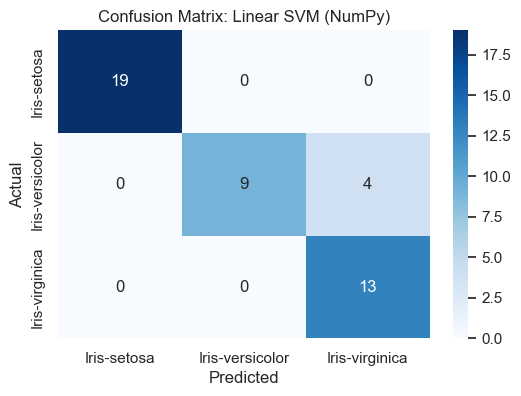

Accuracy: 0.9111



In [12]:
import numpy as np

class LinearSVMScratch:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, iterations=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.iterations = iterations
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        self.w = np.zeros((len(self.classes), n_features))
        self.b = np.zeros(len(self.classes))

        for idx, cls in enumerate(self.classes):
            y_binary = np.where(y == cls, 1, -1)
            w = np.zeros(n_features)
            b = 0
            for epoch in range(1, self.iterations + 1):
                eta = self.lr / (1 + epoch * self.lr) # Learning rate decay
                for i, x_i in enumerate(X):
                    condition = y_binary[i] * (np.dot(x_i, w) - b) >= 1
                    if condition:
                        w -= eta * (2 * self.lambda_param * w)
                    else:
                        w -= eta * (2 * self.lambda_param * w - np.dot(x_i, y_binary[i]))
                        b -= eta * y_binary[i]
            self.w[idx] = w
            self.b[idx] = b

    def predict(self, X):
        scores = np.dot(X, self.w.T) - self.b
        return self.classes[np.argmax(scores, axis=1)]

# Run Linear SVM
lin_svm = LinearSVMScratch(learning_rate=0.1, iterations=1000)
lin_svm.fit(X_train_scaled, y_train)
lin_preds = lin_svm.predict(X_test_scaled)
plot_cm(y_test, lin_preds, "Linear SVM (NumPy)")

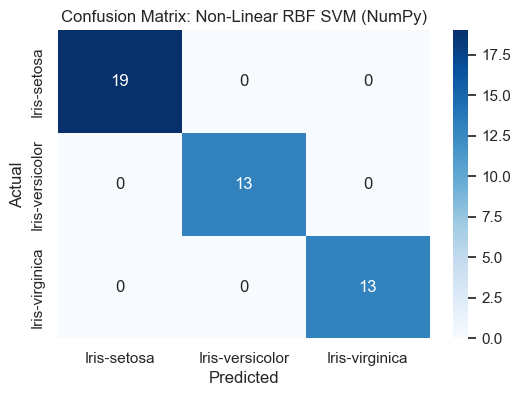

Accuracy: 1.0000



In [13]:
import numpy as np

class KernelSVMScratch:
    def __init__(self, gamma=0.5, C=1.0, iterations=500):
        self.gamma = gamma
        self.C = C
        self.iterations = iterations
        self.models = []

    def _rbf_kernel(self, X1, X2):
        # Vectorized RBF Kernel calculation
        sq_dist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
        return np.exp(-self.gamma * sq_dist)

    def fit(self, X, y):
        self.classes = np.unique(y)
        X = np.array(X)
        for cls in self.classes:
            y_binary = np.where(y == cls, 1.0, -1.0)
            n_samples = X.shape[0]
            alpha = np.zeros(n_samples)
            K = self._rbf_kernel(X, X)
            
            lr = 0.01
            for _ in range(self.iterations):
                # Gradient of Dual Objective
                gradient = 1 - y_binary * (K @ (alpha * y_binary))
                alpha += lr * gradient
                alpha = np.clip(alpha, 0, self.C) # Box constraint
            self.models.append((alpha, y_binary, X))

    def predict(self, X):
        X = np.array(X)
        all_scores = []
        for alpha, y_binary, X_train in self.models:
            K_test = self._rbf_kernel(X, X_train)
            score = K_test @ (alpha * y_binary)
            all_scores.append(score)
        return self.classes[np.argmax(np.array(all_scores), axis=0)]

# Run Non-Linear SVM
rbf_svm = KernelSVMScratch(gamma=0.7, C=1.0)
rbf_svm.fit(X_train_scaled, y_train)
rbf_preds = rbf_svm.predict(X_test_scaled)
plot_cm(y_test, rbf_preds, "Non-Linear RBF SVM (NumPy)")

After that, a more chanllenging challenging train and test dataset split is obtained, to test the function of the five (two SVM) machine learning methods.

In [27]:
# 1. Encode the Species names into numbers (0, 1, 2)
le = LabelEncoder()
y_class = le.fit_transform(df_full['species'])
X_class = df_full.drop('species', axis=1)

# 2. Split (10% Train, 90% Test)
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.9, random_state=42)

# 3. Scaling (Crucial for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('The shape of the scaled training data X is:', X_train_scaled.shape)
print('The shape of the training labels y is:', y_train.shape)
print('The shape of the scaled test data X is:', X_test_scaled.shape)
print('The shape of the test labels y is:', y_test.shape)

The shape of the scaled training data X is: (15, 4)
The shape of the training labels y is: (15,)
The shape of the scaled test data X is: (135, 4)
The shape of the test labels y is: (135,)


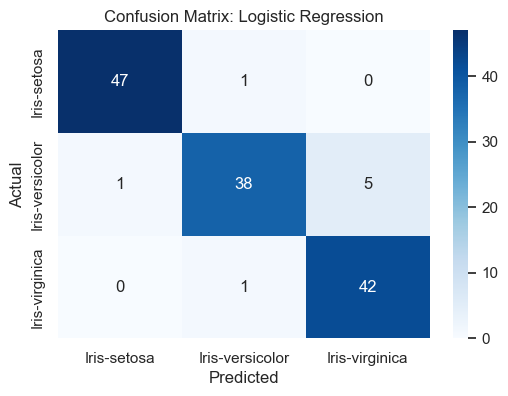

Accuracy: 0.9407



In [28]:
# Logistic Regression

# 1. Create the model
model = LogisticRegression(learning_rate=0.1, iterations=5000)

# 2. Fit the data
model.fit(X_train_scaled, y_train)

# 3. Get predictions
preds = model.predict(X_test_scaled)

# 4. View results
plot_cm(y_test, preds, "Logistic Regression")

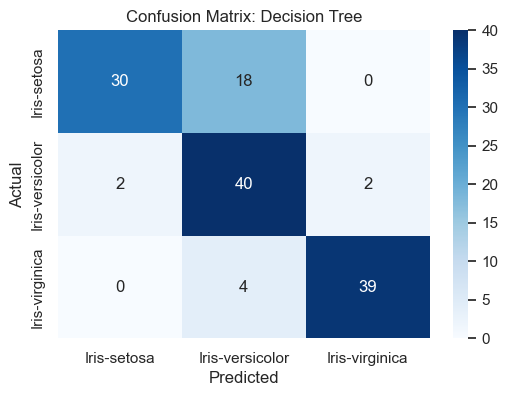

Accuracy: 0.8074



In [29]:
# Decision Tree

dt_model = DecisionTreeScratch(max_depth=3, min_samples_split=2)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

plot_cm(y_test, dt_preds, "Decision Tree")

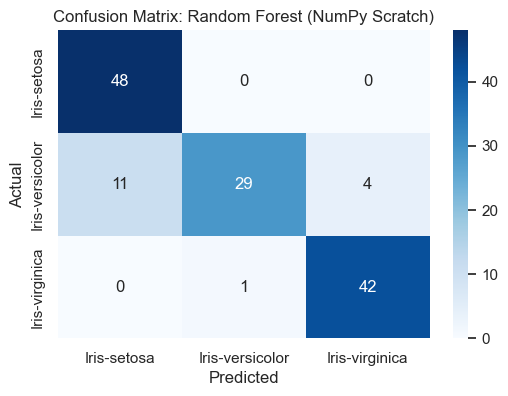

Accuracy: 0.8815



In [30]:
rf_model = RandomForestScratch(n_trees=20, max_depth=3)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

plot_cm(y_test, rf_preds, "Random Forest (NumPy Scratch)")

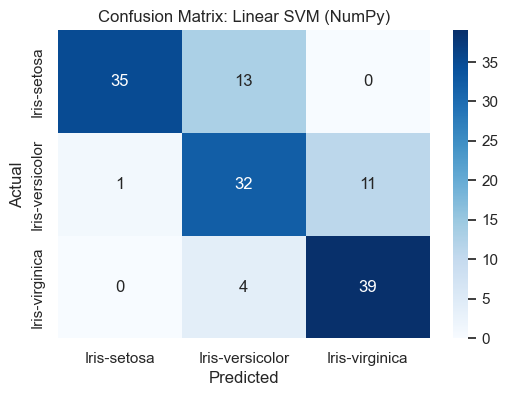

Accuracy: 0.7852



In [31]:
# Linear SVM

lin_svm = LinearSVMScratch(learning_rate=0.1, iterations=1000)
lin_svm.fit(X_train_scaled, y_train)
lin_preds = lin_svm.predict(X_test_scaled)
plot_cm(y_test, lin_preds, "Linear SVM (NumPy)")

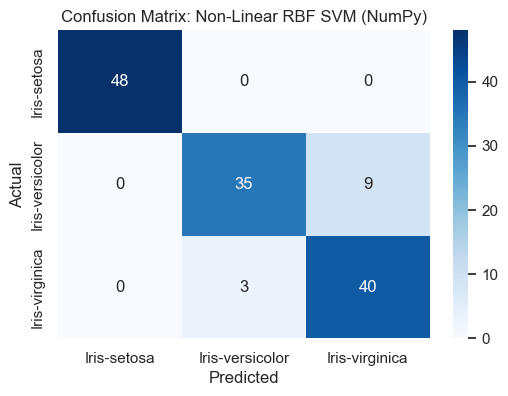

Accuracy: 0.9111



In [32]:
# Non-Linear SVM

rbf_svm = KernelSVMScratch(gamma=0.7, C=1.0)
rbf_svm.fit(X_train_scaled, y_train)
rbf_preds = rbf_svm.predict(X_test_scaled)
plot_cm(y_test, rbf_preds, "Non-Linear RBF SVM (NumPy)")

This exploration of the Iris dataset demonstrates how classical machine learning algorithms can be understood, implemented, and evaluated from first principles. Starting with data loading and visualization, we trained and tested logistic regression, decision trees, random forests, and both linear and kernel-based support vector machines—all coded manually without relying on high-level libraries like scikit-learn for the core logic. Under a standard 70–30 split, most models achieved perfect or near-perfect accuracy, highlighting the dataset’s inherent separability. However, when challenged with a more difficult 10–90 split (only 15 training samples), performance varied significantly: non-linear models like the RBF SVM and logistic regression maintained strong results, while simpler or more rigid models like the linear SVM showed reduced accuracy. These experiments not only validate theoretical concepts—such as margin maximization, ensemble variance reduction, and probabilistic classification—but also underscore the importance of data quantity, feature scaling, and model flexibility in real-world learning scenarios. The Iris dataset, though small, continues to serve as a powerful pedagogical lens through which the mechanics of machine learning come into sharp focus.